In [1]:
# Import packages.

import numpy as np
import matplotlib.pyplot as plt
import json
import qiskit
from qiskit import qasm2
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit.library import QFTGate
from qiskit import transpile, QuantumCircuit
from qiskit_ibm_catalog import QiskitFunctionsCatalog
import random
from qiskit import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeTorino
from math import pi
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate
from scipy.stats import unitary_group
from qward import Scanner, Visualizer
from qward.metrics import CircuitPerformanceMetrics
from qward.visualization.constants import Metrics, Plots

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

IBM_QUANTUM_TOKEN = os.getenv("IBM_QUANTUM_TOKEN_EVIDA")
IBM_QUANTUM_INSTANCE = os.getenv("IBM_QUANTUM_INTANCE_CUA_EVIDA")

QiskitRuntimeService.save_account(
    token=IBM_QUANTUM_TOKEN,
    instance=IBM_QUANTUM_INSTANCE,
    overwrite=True,
)
service = QiskitRuntimeService()
backends = service.backends()
print(f"Account OK. {len(backends)} backend(s) available:")
for b in backends[:5]:
    print(f"  {b.name} ({b.num_qubits} qubits)")

Account OK. 6 backend(s) available:
  ibm_pittsburgh (156 qubits)
  ibm_boston (156 qubits)
  ibm_fez (156 qubits)
  ibm_miami (120 qubits)
  ibm_marrakesh (156 qubits)


In [3]:
catalog = QiskitFunctionsCatalog(channel="ibm_quantum_platform")

qesem_function = catalog.load("qedma/qesem")
perf_mgmt = catalog.load("q-ctrl/performance-management")

In [5]:
shot_count = 10000
n = 5
hidden_string = "".join(random.choice("01") for _ in range(n))
backend = FakeTorino()  # AerSimulator()#
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

# Bernstein-Vazirani

In [6]:
print(f"Hidden string: {hidden_string}")

def create_bv_circuit(hidden_string):
    n = len(hidden_string)
    circuit = QuantumCircuit(n + 1, n)
    circuit.x(n)
    circuit.h(range(n + 1))
    for i, bit in enumerate(hidden_string):
        if bit == "1":
            circuit.cx(i, n)
    circuit.h(range(n))
    circuit.measure(range(n), range(n))
    return circuit

Hidden string: 00100


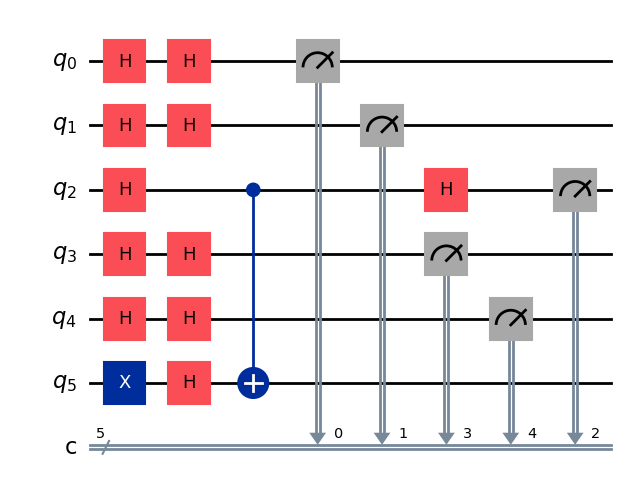

In [7]:
BV = create_bv_circuit(hidden_string)

bv_scan = Scanner(BV).scan()
# bv_scan.summary()
BV.draw("mpl", fold=-1)

In [8]:
isa_qc = pm.run(BV)
sampler = Sampler(mode=backend)
bv_job = sampler.run([isa_qc], shots=shot_count)
sampler_result = bv_job.result()
counts = sampler_result[0].data.c.get_counts()

print("Sampler counts:", counts)

Sampler counts: {'00100': 9701, '00101': 69, '00000': 112, '00110': 27, '10100': 72, '01100': 18, '00010': 1}


In [9]:
def plot_results(results, hidden_bitstring, title, max_columns=20):
    """
    Compute probabilities for all results, but plot only the top max_columns bitstrings.
    The highlighted target is hidden_bitstring[::-1], matching your current convention.
    """

    # Do not modify original results
    raw_results = dict(results)

    # Decide whether input is counts or already probabilities
    total = sum(raw_results.values())

    if total > 1.5:
        # Input is counts
        all_probabilities = {
            bitstring: count / total
            for bitstring, count in raw_results.items()
        }
    else:
        # Input is already probabilities
        all_probabilities = raw_results

    # This is the actual bitstring highlighted in the plot
    target_bitstring = hidden_bitstring[::-1]

    # Select only top bitstrings for plotting
    if max_columns is not None:
        plot_bitstrings = sorted(
            all_probabilities.keys(),
            key=lambda x: all_probabilities[x],
            reverse=True
        )[:max_columns]

        # Always include target in the plot, even if it is not top 20
        if target_bitstring not in plot_bitstrings:
            plot_bitstrings.append(target_bitstring)
    else:
        plot_bitstrings = list(all_probabilities.keys())

    # Sort plotted bitstrings for readable x-axis
    plot_bitstrings = sorted(plot_bitstrings)

    plot_probabilities = [
        all_probabilities.get(bitstring, 0)
        for bitstring in plot_bitstrings
    ]

    plt.figure(figsize=(20, 5))
    bars = plt.bar(plot_bitstrings, plot_probabilities)
    plt.xticks(rotation=90)

    for index, bitstring in enumerate(plot_bitstrings):
        if bitstring == target_bitstring:
            bars[index].set_color("green")
        else:
            bars[index].set_color("gray")

    plt.ylabel("Probability")
    plt.ylim([0, 1])
    plt.title(title)
    plt.show()

    return all_probabilities


def bitstring_count_to_probabilities(data, shot_count, number_of_counting_qubits):
    """
    Convert bitstring counts to probabilities.
    """
    probabilities = {
        format(int(bitstring, 2), f"0{number_of_counting_qubits}b"): (
            bitstring_count / shot_count
        )
        for bitstring, bitstring_count in data.items()
    }
    return probabilities

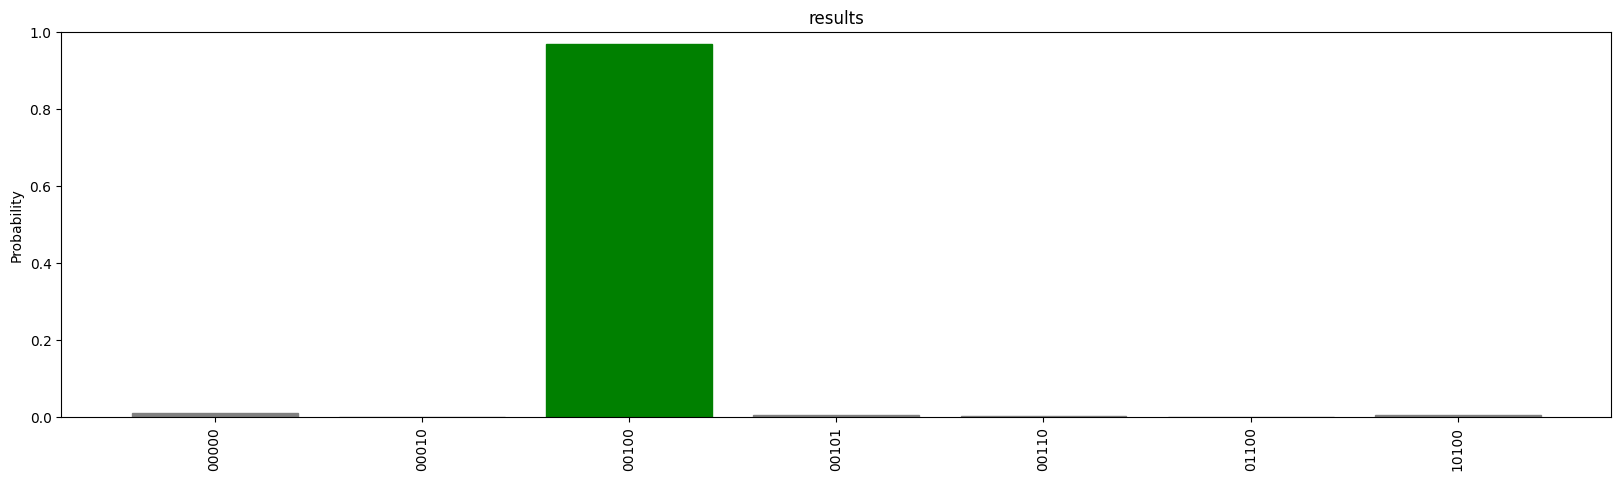

Probabilities: {'00100': 0.9701, '00101': 0.0069, '00000': 0.0112, '00110': 0.0027, '10100': 0.0072, '01100': 0.0018, '00010': 0.0001}
Success probability: 97.01%


In [10]:
Prob_bv = plot_results(
    counts,
    hidden_bitstring=hidden_string,
    title="results",
    max_columns=20,
)
print("Probabilities:", Prob_bv)

results = bitstring_count_to_probabilities(
    counts, shot_count, number_of_counting_qubits=len(hidden_string)
)
hidden_bitstring = hidden_string[::-1]
if hidden_bitstring not in results:
    print("The hidden_bitstring has 0% probability.")
else:
    print(f"Success probability: {100 * results.get(hidden_bitstring, 0):.2f}%")

## QWARD Visualization - Bernstein-Vazirani

In [11]:
from qiskit_aer.noise import NoiseModel


def bv_success_criteria(outcome):
    """BV success: measured bitstring matches hidden_string (reversed due to qiskit ordering)."""
    clean = outcome.replace(" ", "")
    return clean == hidden_string[::-1]


noisy_sim = AerSimulator(noise_model=NoiseModel.from_backend(backend))
bv_noisy_job = noisy_sim.run(transpile(BV, noisy_sim), shots=shot_count)

bv_perf_scan = (
    Scanner(BV)
    .add(
        CircuitPerformanceMetrics,
        job=bv_noisy_job,
        success_criteria=bv_success_criteria,
        expected_outcomes=[hidden_string[::-1]],
    )
    .scan(include_all_pre_runtime=False)
)
bv_perf_scan.summary()


🎯 QWARD ANALYSIS SUMMARY

📋 Circuit Performance Analysis:
   Jobs analyzed: 1
   Job 1: 72.3% success (10000 shots)


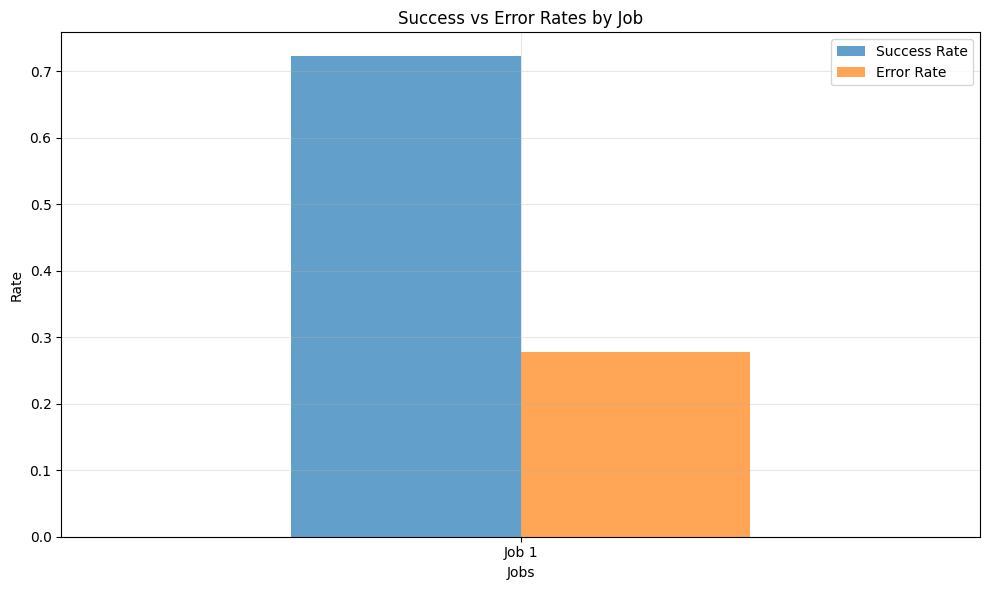

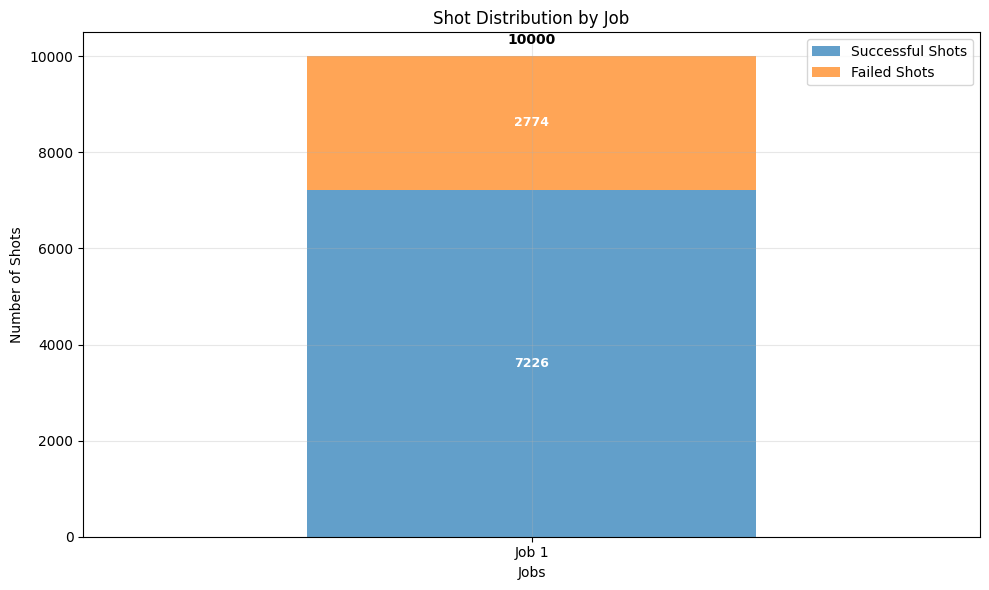

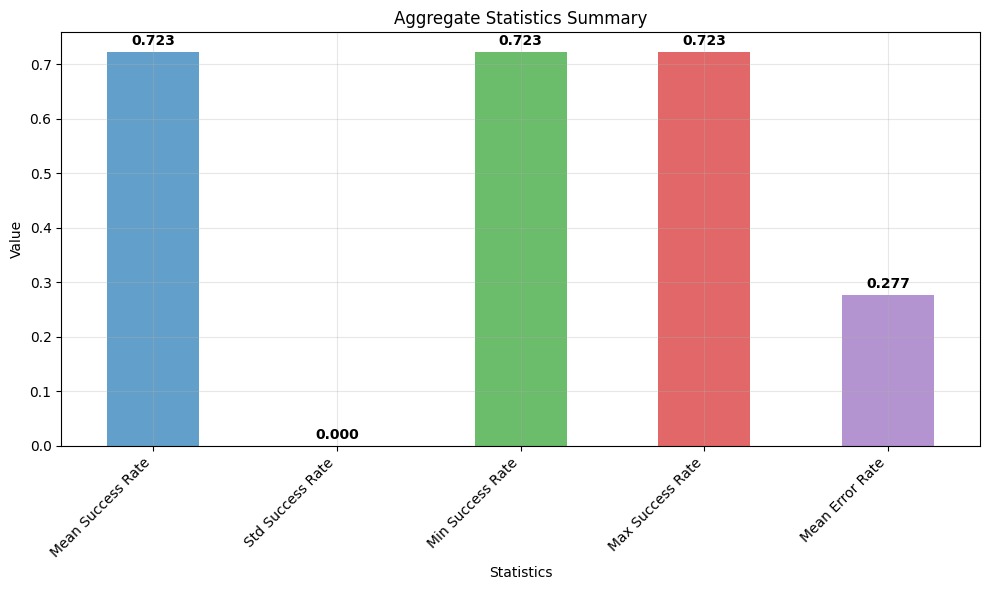

{'CircuitPerformance': {'success_error_comparison': <Figure size 1000x600 with 1 Axes>,
  'shot_distribution': <Figure size 1000x600 with 1 Axes>,
  'aggregate_summary': <Figure size 1000x600 with 1 Axes>}}

In [12]:
bv_visualizer = Visualizer(metrics_data=bv_perf_scan.to_dict())
bv_visualizer.generate_plots(
    selections={Metrics.CIRCUIT_PERFORMANCE: None},
    save=False,
    show=True,
)

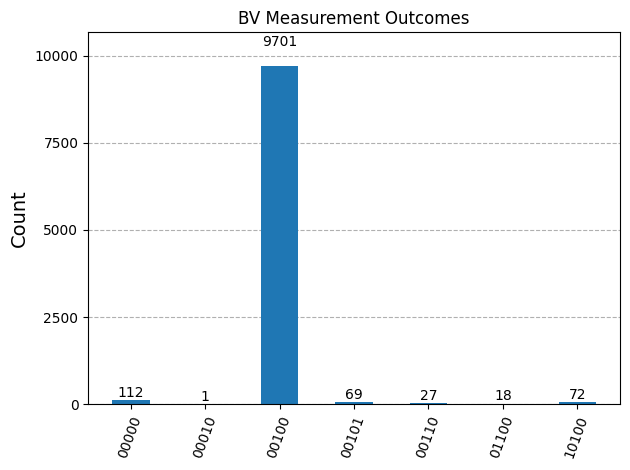

In [13]:
from qiskit.visualization import plot_histogram

plot_histogram(counts, title="BV Measurement Outcomes")

## BV Benchmark Summary Table

In [14]:
import pandas as pd
from qward.metrics.differential_success_rate import compute_dsr_michelson

# Full scan: pre-runtime + post-runtime (with DSR) in one Scanner pass
bv_full_scan = (
    Scanner(BV)
    .add(
        CircuitPerformanceMetrics,
        job=bv_noisy_job,
        success_criteria=bv_success_criteria,
        expected_outcomes=[hidden_string[::-1]],
    )
    .scan(include_all_pre_runtime=True)
)

# Build DataFrame from qward ScanResult
bv_metrics_df = pd.concat(
    {name: df for name, df in bv_full_scan.items()},
    axis=1,
)
bv_metrics_df.columns = [f"{lvl0}.{lvl1}" for lvl0, lvl1 in bv_metrics_df.columns]

print("=== BV Benchmark: Pre-Runtime + Post-Runtime (DSR) ===")
bv_metrics_df.T

=== BV Benchmark: Pre-Runtime + Post-Runtime (DSR) ===


,0
CircuitPerformance.individual_jobs.success_metrics.success_rate,0.7226
CircuitPerformance.individual_jobs.success_metrics.error_rate,0.2774
CircuitPerformance.individual_jobs.success_metrics.total_shots,10000
CircuitPerformance.individual_jobs.success_metrics.successful_shots,7226
CircuitPerformance.individual_jobs.statistical_metrics.entropy,1.504112
CircuitPerformance.individual_jobs.statistical_metrics.uniformity,0.332506
CircuitPerformance.individual_jobs.statistical_metrics.concentration,0.667494
CircuitPerformance.individual_jobs.statistical_metrics.dominant_outcome_probability,0.7226
CircuitPerformance.individual_jobs.statistical_metrics.num_unique_outcomes,23
CircuitPerformance.individual_jobs.dsr_metrics.dsr_michelson,0.675012


# QFT

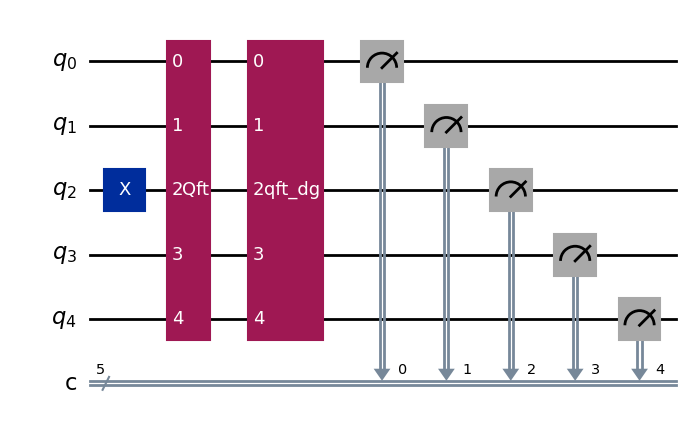

In [15]:
def create_FT_circuit(hidden_string):
    FT = QuantumCircuit(n, n)
    for i, bit in enumerate(reversed(hidden_string)):
        if bit == "1":
            FT.x(i)
    FT.append(QFTGate(n), range(n))
    FT.append(QFTGate(n).inverse(), range(n))
    FT.measure(range(n), range(n))
    return FT


FT = create_FT_circuit(hidden_string)
FT.draw("mpl", fold=-1)

In [17]:
isa_qc = pm.run(FT)
sampler = Sampler(mode=backend)
sampler_result = sampler.run([isa_qc], shots=shot_count).result()
counts = sampler_result[0].data.c.get_counts()

print("Sampler counts:", counts)

Sampler counts: {'00100': 7469, '10100': 735, '00000': 143, '00101': 378, '01000': 92, '10110': 73, '01101': 23, '10101': 123, '01100': 197, '11100': 185, '10111': 6, '00110': 251, '00010': 34, '00011': 8, '00001': 40, '11000': 28, '10000': 49, '01110': 26, '01001': 22, '10010': 7, '10001': 10, '11101': 21, '00111': 12, '11110': 36, '11001': 13, '11111': 2, '01010': 8, '01111': 4, '10011': 2, '11010': 2, '01011': 1}


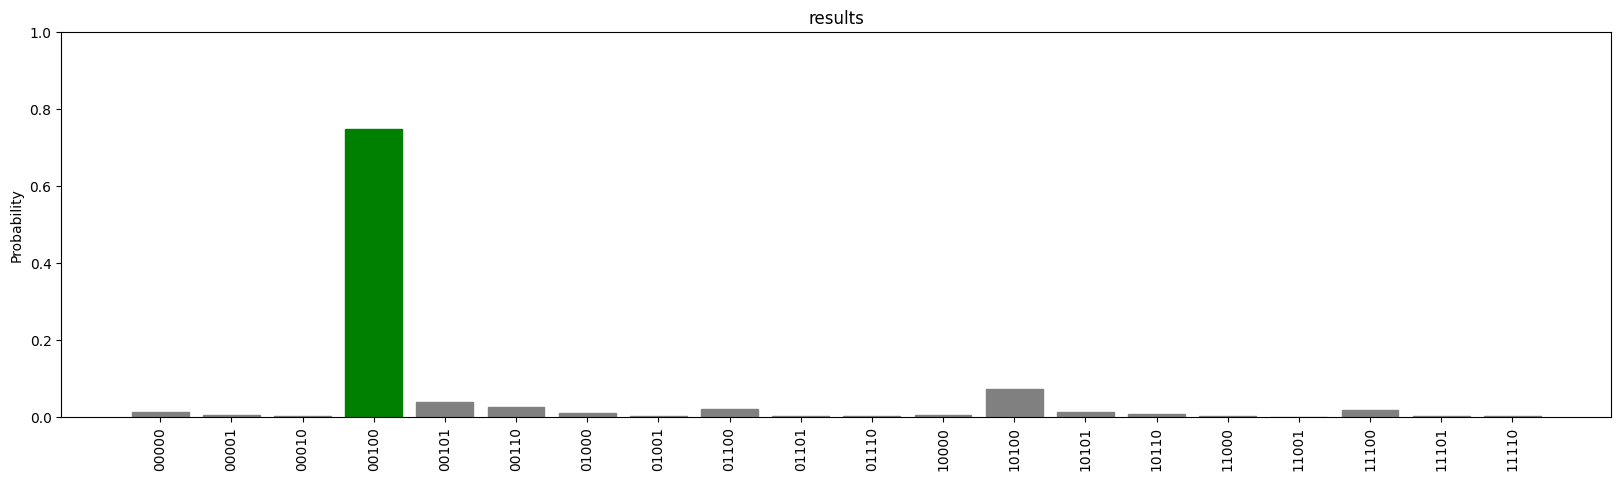

Probabilities: {'00100': 0.7469, '10100': 0.0735, '00000': 0.0143, '00101': 0.0378, '01000': 0.0092, '10110': 0.0073, '01101': 0.0023, '10101': 0.0123, '01100': 0.0197, '11100': 0.0185, '10111': 0.0006, '00110': 0.0251, '00010': 0.0034, '00011': 0.0008, '00001': 0.004, '11000': 0.0028, '10000': 0.0049, '01110': 0.0026, '01001': 0.0022, '10010': 0.0007, '10001': 0.001, '11101': 0.0021, '00111': 0.0012, '11110': 0.0036, '11001': 0.0013, '11111': 0.0002, '01010': 0.0008, '01111': 0.0004, '10011': 0.0002, '11010': 0.0002, '01011': 0.0001}
Success probability: 74.69%


In [19]:
Prob_FT = plot_results(
    counts,
    hidden_bitstring=hidden_string[::-1],
    title="results",
    max_columns=20,
)
print("Probabilities:", Prob_FT)

results = bitstring_count_to_probabilities(
    counts, shot_count, number_of_counting_qubits=len(hidden_string)
)
hidden_bitstring = hidden_string
if hidden_bitstring not in results:
    print("The hidden_bitstring has 0% probability.")
else:
    print(f"Success probability: {100 * results.get(hidden_bitstring, 0):.2f}%")

## QWARD Visualization - QFT

In [20]:
def qft_success_criteria(outcome):
    """QFT roundtrip success: output matches input hidden_string."""
    clean = outcome.replace(" ", "")
    return clean == hidden_string


qft_noisy_job = noisy_sim.run(transpile(FT, noisy_sim), shots=shot_count)

qft_perf_scan = (
    Scanner(FT)
    .add(
        CircuitPerformanceMetrics,
        job=qft_noisy_job,
        success_criteria=qft_success_criteria,
        expected_outcomes=[hidden_string],
    )
    .scan(include_all_pre_runtime=False)
)
qft_perf_scan.summary()


🎯 QWARD ANALYSIS SUMMARY

📋 Circuit Performance Analysis:
   Jobs analyzed: 1
   Job 1: 67.1% success (10000 shots)


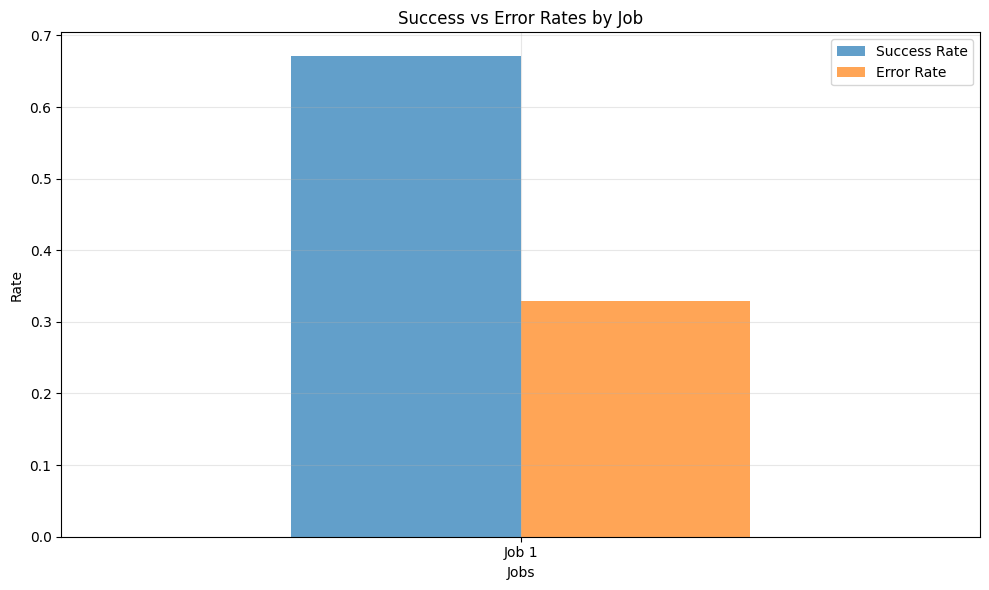

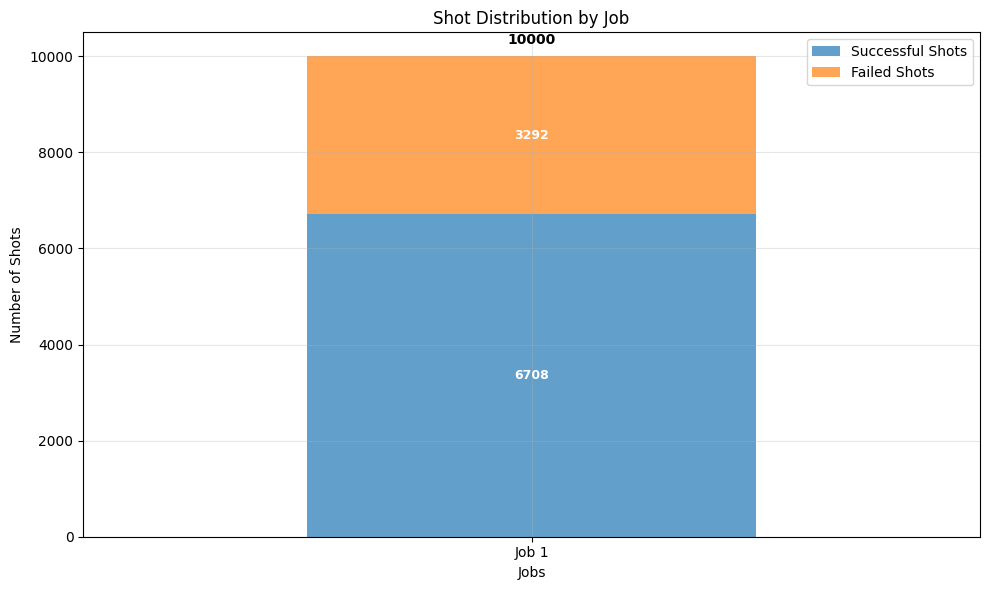

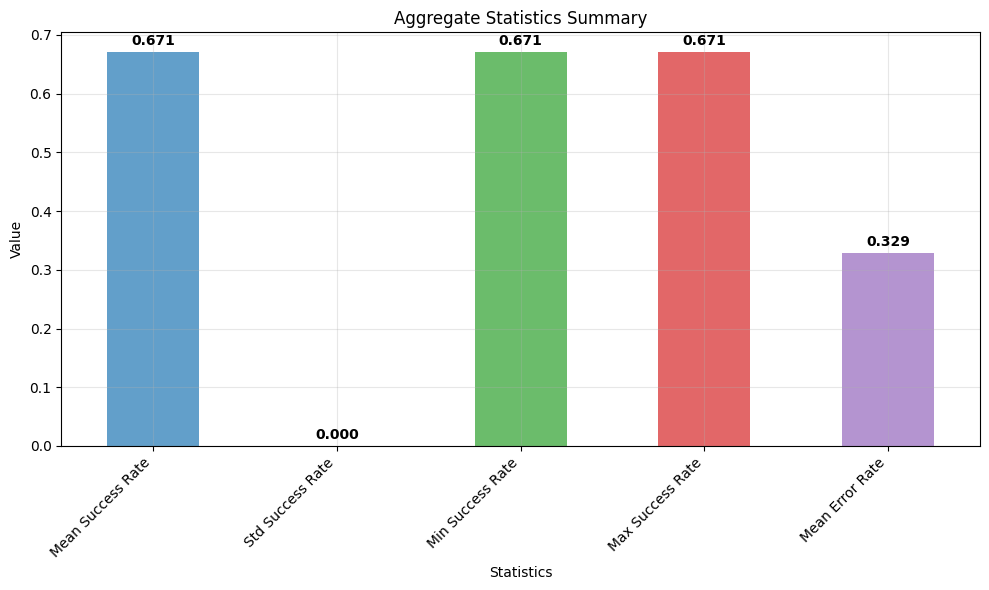

{'CircuitPerformance': {'success_error_comparison': <Figure size 1000x600 with 1 Axes>,
  'shot_distribution': <Figure size 1000x600 with 1 Axes>,
  'aggregate_summary': <Figure size 1000x600 with 1 Axes>}}

In [21]:
qft_visualizer = Visualizer(metrics_data=qft_perf_scan.to_dict())
qft_visualizer.generate_plots(
    selections={Metrics.CIRCUIT_PERFORMANCE: None},
    save=False,
    show=True,
)

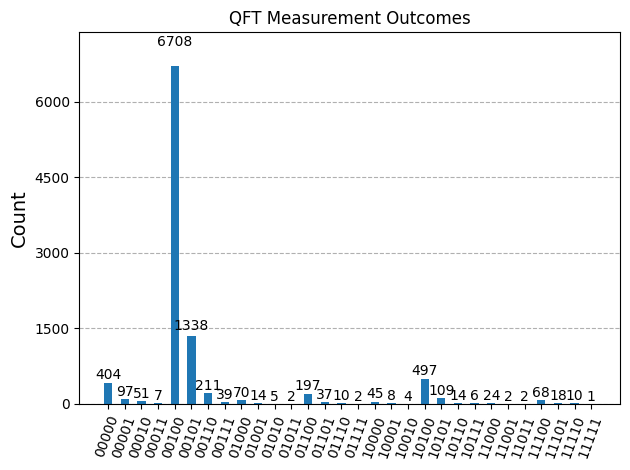

In [22]:
plot_histogram(qft_noisy_job.result().get_counts(), title="QFT Measurement Outcomes")

## QFT Benchmark Summary Table

In [23]:
# Full scan: pre-runtime + post-runtime (with DSR)
qft_full_scan = (
    Scanner(FT)
    .add(
        CircuitPerformanceMetrics,
        job=qft_noisy_job,
        success_criteria=qft_success_criteria,
        expected_outcomes=[hidden_string],
    )
    .scan(include_all_pre_runtime=True)
)

# Build DataFrame from qward ScanResult
qft_metrics_df = pd.concat(
    {name: df for name, df in qft_full_scan.items()},
    axis=1,
)
qft_metrics_df.columns = [f"{lvl0}.{lvl1}" for lvl0, lvl1 in qft_metrics_df.columns]

print("=== QFT Benchmark: Pre-Runtime + Post-Runtime (DSR) ===")
qft_metrics_df.T

=== QFT Benchmark: Pre-Runtime + Post-Runtime (DSR) ===


,0
CircuitPerformance.individual_jobs.success_metrics.success_rate,0.6708
CircuitPerformance.individual_jobs.success_metrics.error_rate,0.3292
CircuitPerformance.individual_jobs.success_metrics.total_shots,10000
CircuitPerformance.individual_jobs.success_metrics.successful_shots,6708
CircuitPerformance.individual_jobs.statistical_metrics.entropy,1.902954
CircuitPerformance.individual_jobs.statistical_metrics.uniformity,0.387813
CircuitPerformance.individual_jobs.statistical_metrics.concentration,0.612187
CircuitPerformance.individual_jobs.statistical_metrics.dominant_outcome_probability,0.6708
CircuitPerformance.individual_jobs.statistical_metrics.num_unique_outcomes,30
CircuitPerformance.individual_jobs.dsr_metrics.dsr_michelson,0.667412


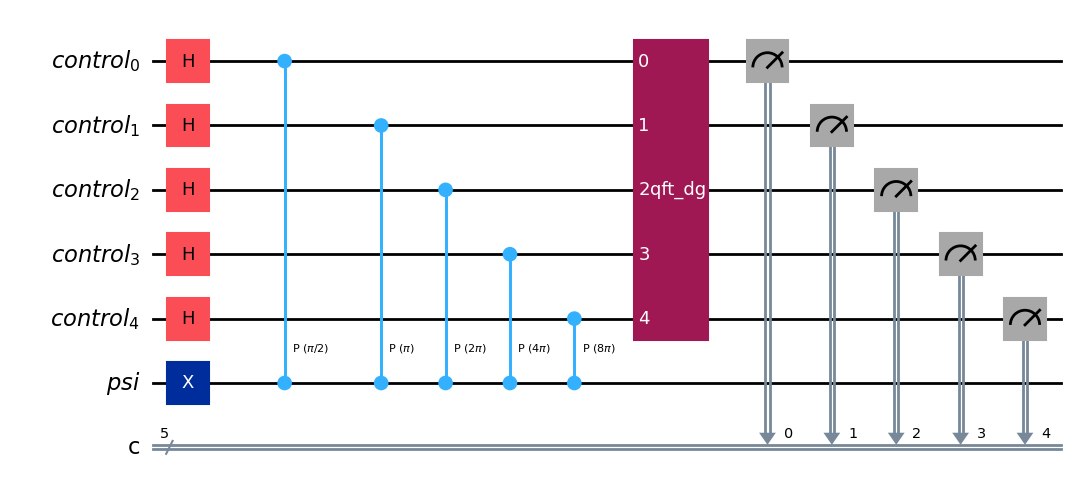

In [24]:
theta = 0.25
m = n

def expected_qpe_bitstring(theta, m):
    k = round(theta * 2**m) % (2**m)
    return format(k, f"0{m}b")

expected = expected_qpe_bitstring(theta, m)

def create_QPE_circuit(theta, m):
    control = QuantumRegister(m, "control")
    target = QuantumRegister(1, "psi")
    result = ClassicalRegister(m, "c")
    qc = QuantumCircuit(control, target, result)
    qc.x(target[0])
    for j in range(m):
        qc.h(control[j])
        angle = 2 * pi * theta * (2**j)
        qc.cp(angle, control[j], target[0])
    qc.compose(QFTGate(m).inverse(), qubits=control, inplace=True)
    qc.measure(control, result)
    return qc

QPE = create_QPE_circuit(theta, m)
QPE.draw("mpl", fold=-1)

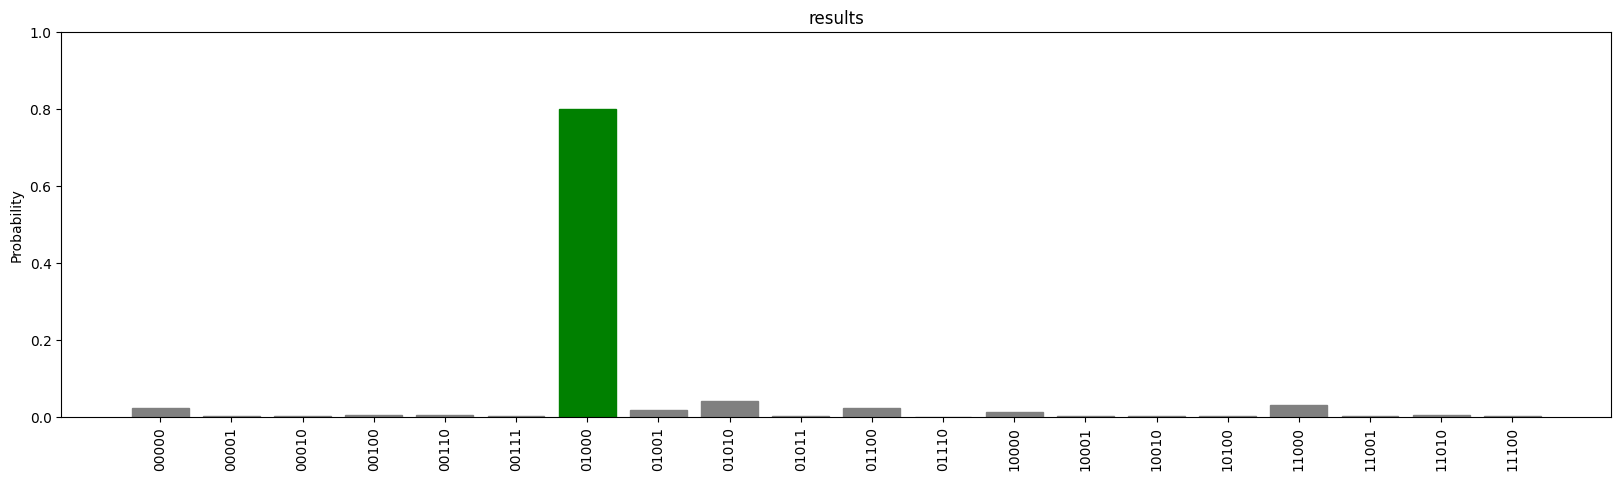

Probabilities: {'00110': 0.0044, '00111': 0.0034, '01000': 0.7996, '10101': 0.0005, '01010': 0.0426, '01100': 0.0228, '11000': 0.0309, '00000': 0.0234, '00100': 0.0057, '01001': 0.0193, '10010': 0.002, '11010': 0.0066, '10000': 0.0132, '10111': 0.0003, '00010': 0.0034, '01011': 0.0023, '10100': 0.0017, '01110': 0.0015, '00001': 0.0029, '11100': 0.0026, '00101': 0.0015, '11001': 0.0027, '01101': 0.0011, '10001': 0.0025, '11110': 0.0006, '10110': 0.0004, '01111': 0.0004, '10011': 0.0004, '11111': 0.0004, '00011': 0.0006, '11011': 0.0001, '11101': 0.0002}
Success probability: 79.96%


In [25]:
isa_qc = pm.run(QPE)
sampler = Sampler(mode=backend)
sampler_result = sampler.run([isa_qc], shots=shot_count).result()
counts = sampler_result[0].data.c.get_counts()

Prob_QPE = plot_results(
    counts,
    hidden_bitstring=expected[::-1],
    title="results",
    max_columns=20,
)
print("Probabilities:", Prob_QPE)

results = bitstring_count_to_probabilities(
    counts, shot_count, number_of_counting_qubits=len(expected)
)
hidden_bitstring = expected
if hidden_bitstring not in results:
    print("The hidden_bitstring has 0% probability.")
else:
    print(f"Success probability: {100 * results.get(hidden_bitstring, 0):.2f}%")

## QWARD Visualization - QPE

In [26]:
def qpe_success_criteria(outcome):
    """QPE success: measured bitstring matches expected phase estimation."""
    clean = outcome.replace(" ", "")
    return clean == expected


qpe_noisy_job = noisy_sim.run(transpile(QPE, noisy_sim), shots=shot_count)

qpe_perf_scan = (
    Scanner(QPE)
    .add(
        CircuitPerformanceMetrics,
        job=qpe_noisy_job,
        success_criteria=qpe_success_criteria,
        expected_outcomes=[expected],
    )
    .scan(include_all_pre_runtime=False)
)
qpe_perf_scan.summary()


🎯 QWARD ANALYSIS SUMMARY

📋 Circuit Performance Analysis:
   Jobs analyzed: 1
   Job 1: 68.0% success (10000 shots)


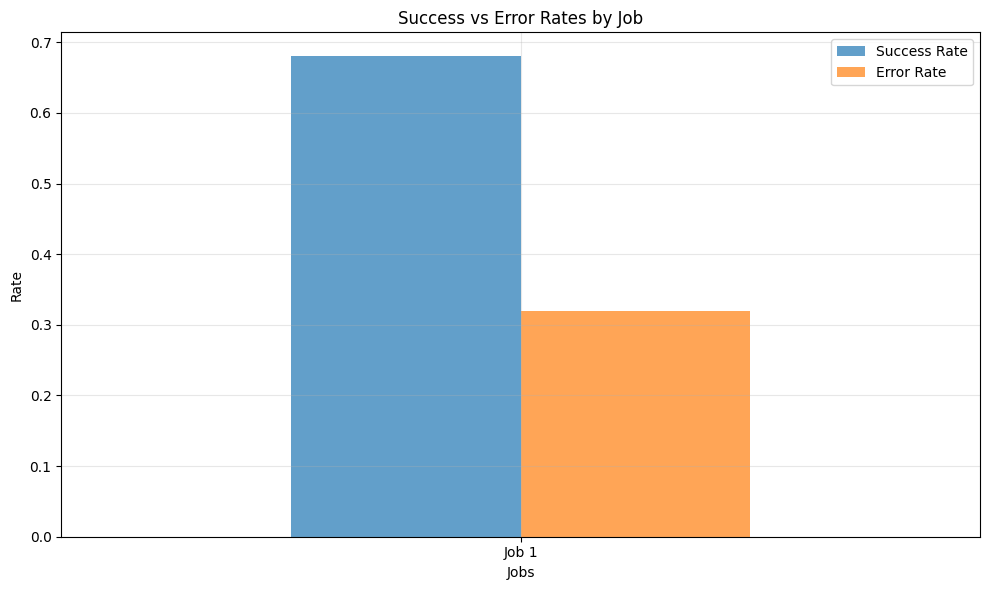

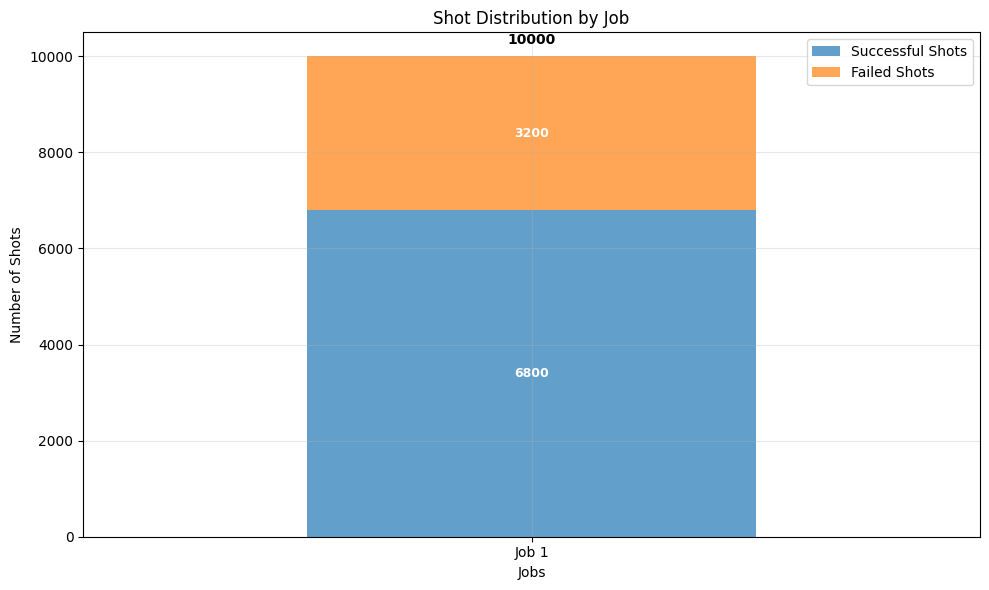

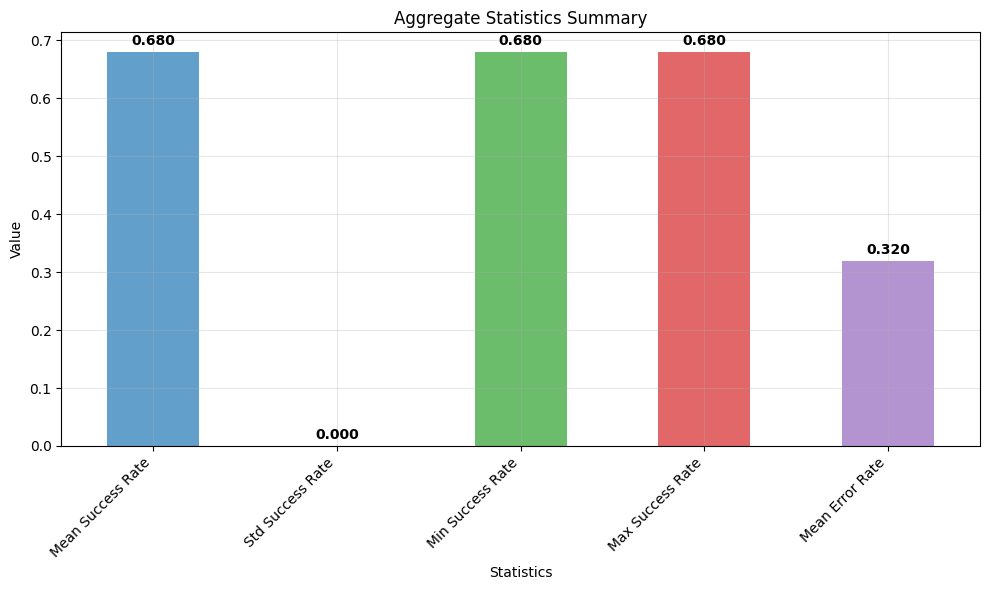

{'CircuitPerformance': {'success_error_comparison': <Figure size 1000x600 with 1 Axes>,
  'shot_distribution': <Figure size 1000x600 with 1 Axes>,
  'aggregate_summary': <Figure size 1000x600 with 1 Axes>}}

In [27]:
qpe_visualizer = Visualizer(metrics_data=qpe_perf_scan.to_dict())
qpe_visualizer.generate_plots(
    selections={Metrics.CIRCUIT_PERFORMANCE: None},
    save=False,
    show=True,
)

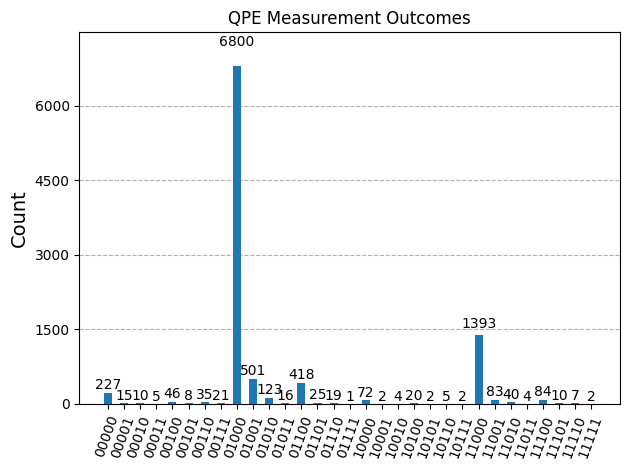

In [28]:
plot_histogram(qpe_noisy_job.result().get_counts(), title="QPE Measurement Outcomes")

## QPE Benchmark Summary Table

In [29]:
# Full scan: pre-runtime + post-runtime (with DSR)
qpe_full_scan = (
    Scanner(QPE)
    .add(
        CircuitPerformanceMetrics,
        job=qpe_noisy_job,
        success_criteria=qpe_success_criteria,
        expected_outcomes=[expected],
    )
    .scan(include_all_pre_runtime=True)
)

# Build DataFrame from qward ScanResult
qpe_metrics_df = pd.concat(
    {name: df for name, df in qpe_full_scan.items()},
    axis=1,
)
qpe_metrics_df.columns = [f"{lvl0}.{lvl1}" for lvl0, lvl1 in qpe_metrics_df.columns]

print("=== QPE Benchmark: Pre-Runtime + Post-Runtime (DSR) ===")
qpe_metrics_df.T

=== QPE Benchmark: Pre-Runtime + Post-Runtime (DSR) ===


,0
CircuitPerformance.individual_jobs.success_metrics.success_rate,0.68
CircuitPerformance.individual_jobs.success_metrics.error_rate,0.32
CircuitPerformance.individual_jobs.success_metrics.total_shots,10000
CircuitPerformance.individual_jobs.success_metrics.successful_shots,6800
CircuitPerformance.individual_jobs.statistical_metrics.entropy,1.817996
CircuitPerformance.individual_jobs.statistical_metrics.uniformity,0.366961
CircuitPerformance.individual_jobs.statistical_metrics.concentration,0.633039
CircuitPerformance.individual_jobs.statistical_metrics.dominant_outcome_probability,0.68
CircuitPerformance.individual_jobs.statistical_metrics.num_unique_outcomes,31
CircuitPerformance.individual_jobs.dsr_metrics.dsr_michelson,0.659954


# Quantum Volume Random Layers

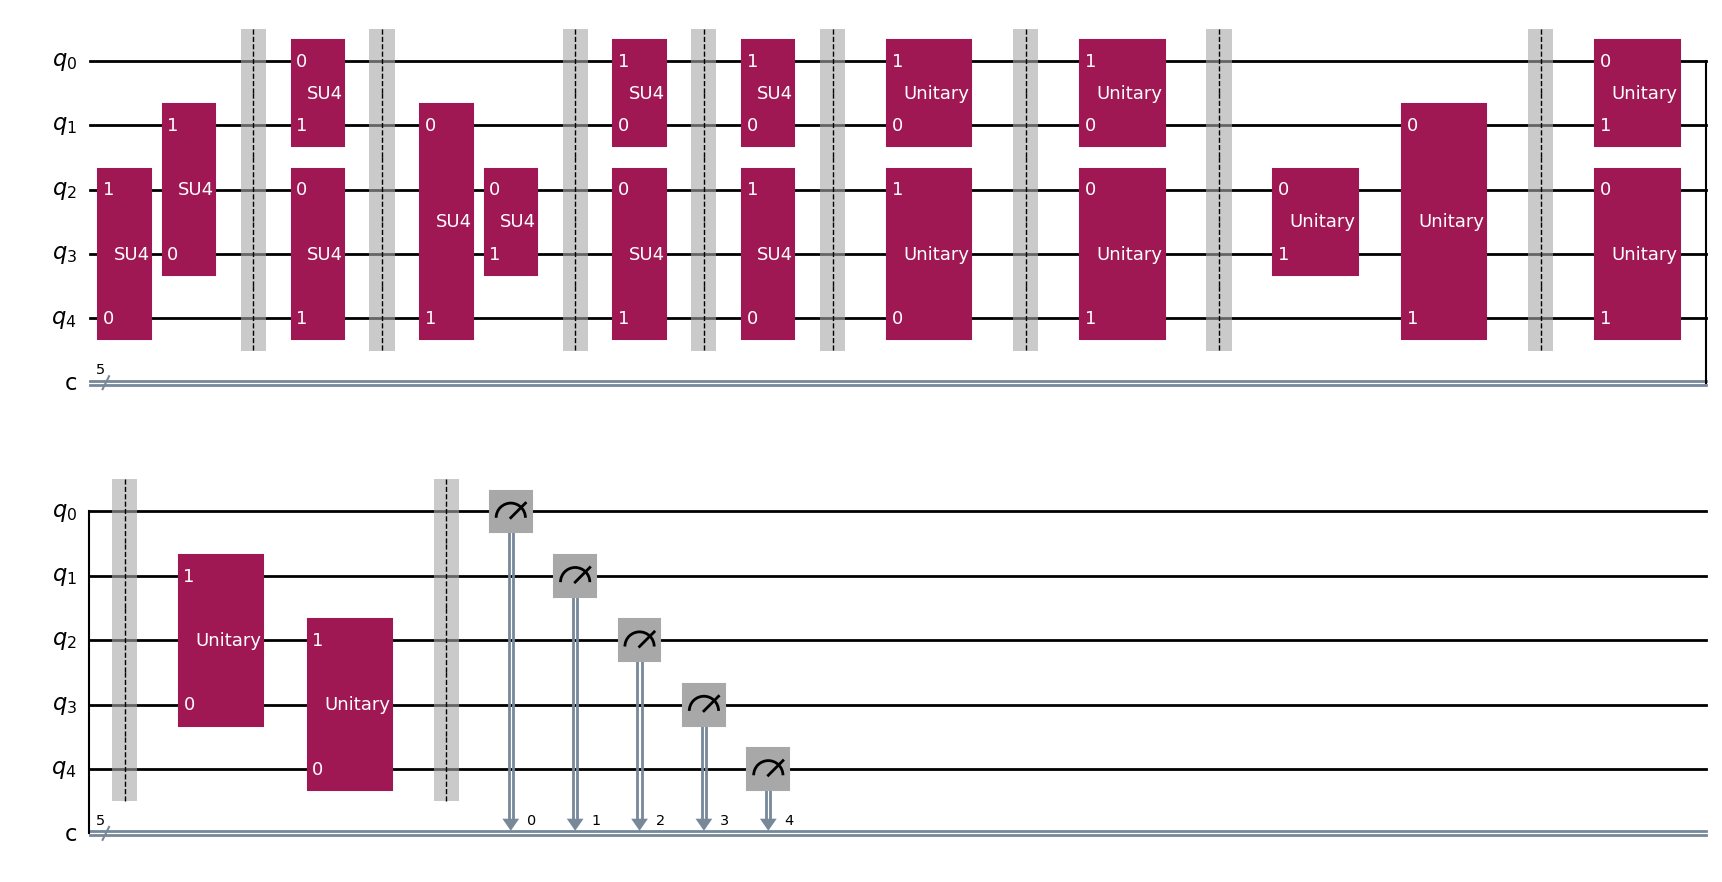

In [30]:
def random_su4_gate(seed=None):
    rng = np.random.default_rng(seed)
    U = unitary_group.rvs(4, random_state=rng)
    return UnitaryGate(U, label="SU4")


def create_RND_circuit(n, depth=None, seed=123):
    if depth is None:
        depth = n
    rng = np.random.default_rng(seed)
    qc = QuantumCircuit(n, n)
    layers = []
    for layer in range(depth):
        perm = rng.permutation(n)
        layer_gates = []
        for i in range(0, n - 1, 2):
            q1 = int(perm[i])
            q2 = int(perm[i + 1])

            gate_seed = int(rng.integers(0, 10**9))
            su4 = random_su4_gate(seed=gate_seed)

            qc.append(su4, [q1, q2])
            layer_gates.append((su4, q1, q2))

        qc.barrier()
        layers.append(layer_gates)
    for layer_gates in reversed(layers):
        for su4, q1, q2 in reversed(layer_gates):
            qc.append(su4.inverse(), [q1, q2])
        qc.barrier()

    qc.measure(range(n), range(n))
    return qc


RND = create_RND_circuit(n=5, depth=5, seed=42)
RND.draw("mpl")

In [31]:
isa_qc = pm.run(RND)
sampler = Sampler(mode=backend)
sampler_result = sampler.run([isa_qc], shots=shot_count).result()
counts = sampler_result[0].data.c.get_counts()

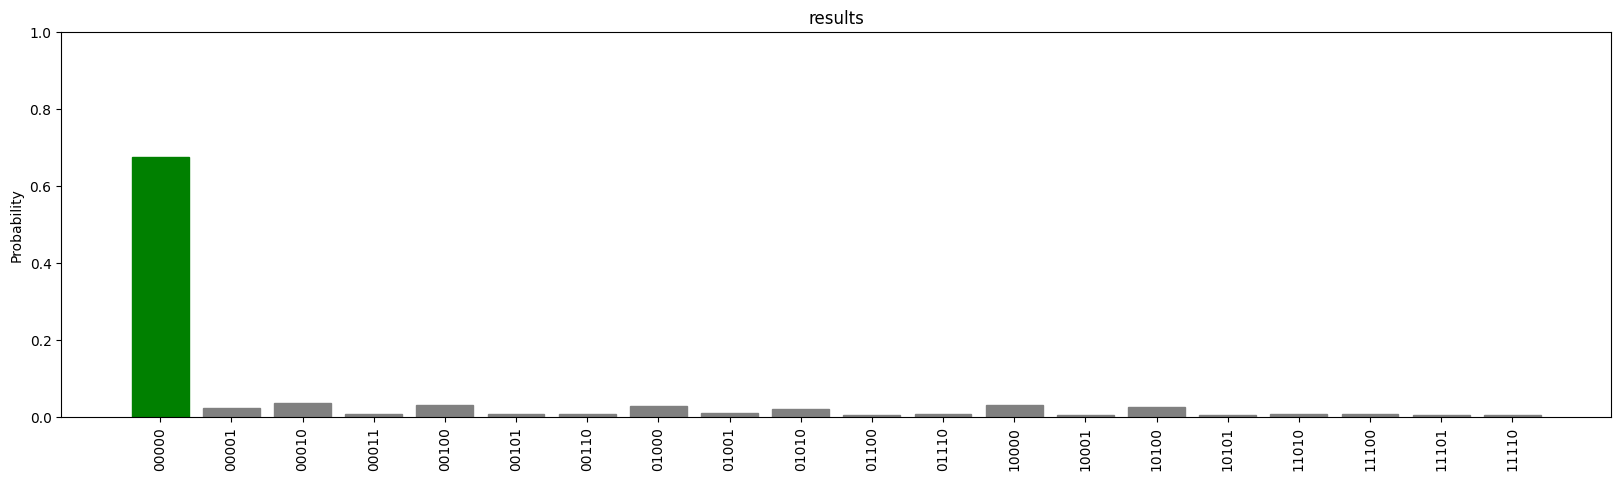

Probabilities: {'00000': 0.6745, '00100': 0.0316, '00011': 0.0085, '01110': 0.007, '10000': 0.0317, '10100': 0.0269, '01000': 0.0277, '11010': 0.008, '11110': 0.0058, '00001': 0.0234, '00010': 0.0353, '00110': 0.0071, '01010': 0.0221, '11100': 0.0067, '01011': 0.0023, '01001': 0.011, '10110': 0.0055, '11101': 0.0063, '10011': 0.0031, '11001': 0.0026, '10001': 0.0059, '10010': 0.0056, '10101': 0.0065, '00111': 0.0042, '00101': 0.0072, '01101': 0.0051, '01100': 0.0061, '10111': 0.0054, '01111': 0.001, '11111': 0.0017, '11011': 0.0009, '11000': 0.0033}
Success probability: 67.45%


In [32]:
Prob_RDN = plot_results(
    counts,
    hidden_bitstring="0" * n,
    title="results",
    max_columns=20,
)
print("Probabilities:", Prob_RDN)

results = bitstring_count_to_probabilities(
    counts, shot_count, number_of_counting_qubits=n
)
hidden_bitstring = "0" * n
if hidden_bitstring not in results:
    print("The hidden_bitstring has 0% probability.")
else:
    print(f"Success probability: {100 * results.get(hidden_bitstring, 0):.2f}%")

## QWARD Visualization - Random Layers

In [33]:
def rnd_success_criteria(outcome):
    """Random Layers success: inverse layers return state to |0...0>."""
    clean = outcome.replace(" ", "")
    return clean == "0" * n


rnd_noisy_job = noisy_sim.run(transpile(RND, noisy_sim), shots=shot_count)

rnd_perf_scan = (
    Scanner(RND)
    .add(
        CircuitPerformanceMetrics,
        job=rnd_noisy_job,
        success_criteria=rnd_success_criteria,
        expected_outcomes=["0" * n],
    )
    .scan(include_all_pre_runtime=False)
)
rnd_perf_scan.summary()


🎯 QWARD ANALYSIS SUMMARY

📋 Circuit Performance Analysis:
   Jobs analyzed: 1
   Job 1: 58.6% success (10000 shots)


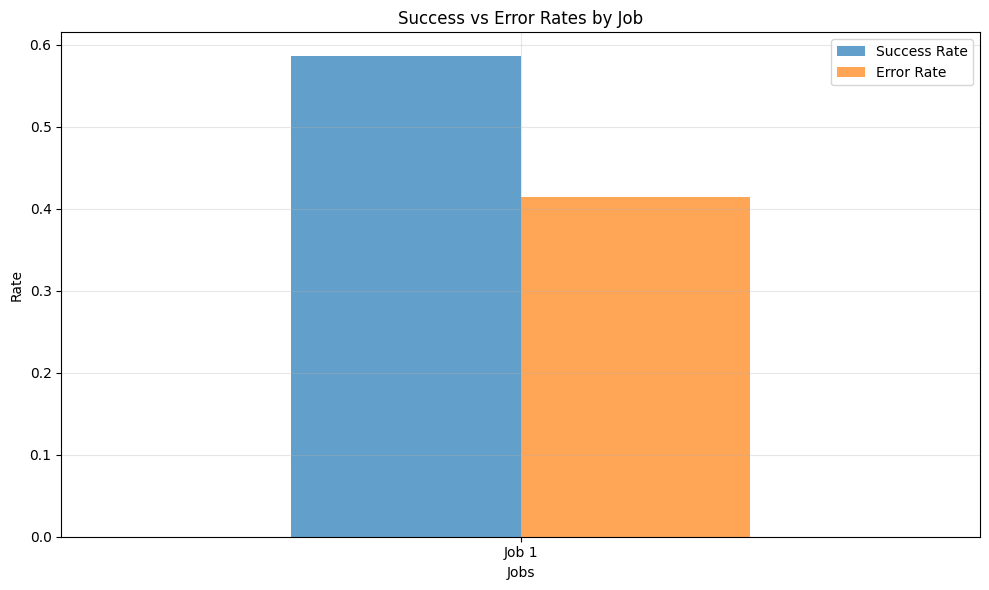

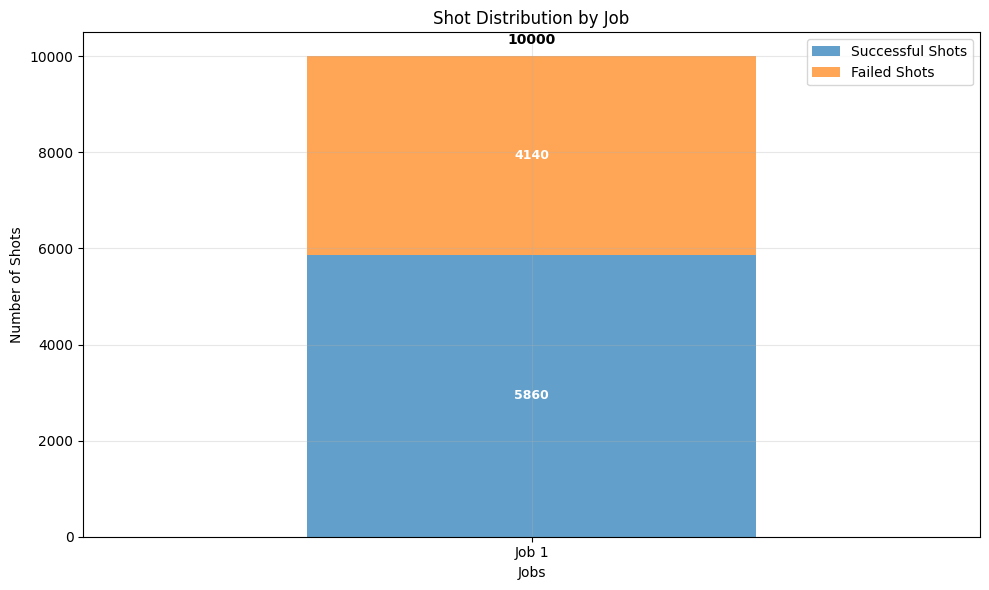

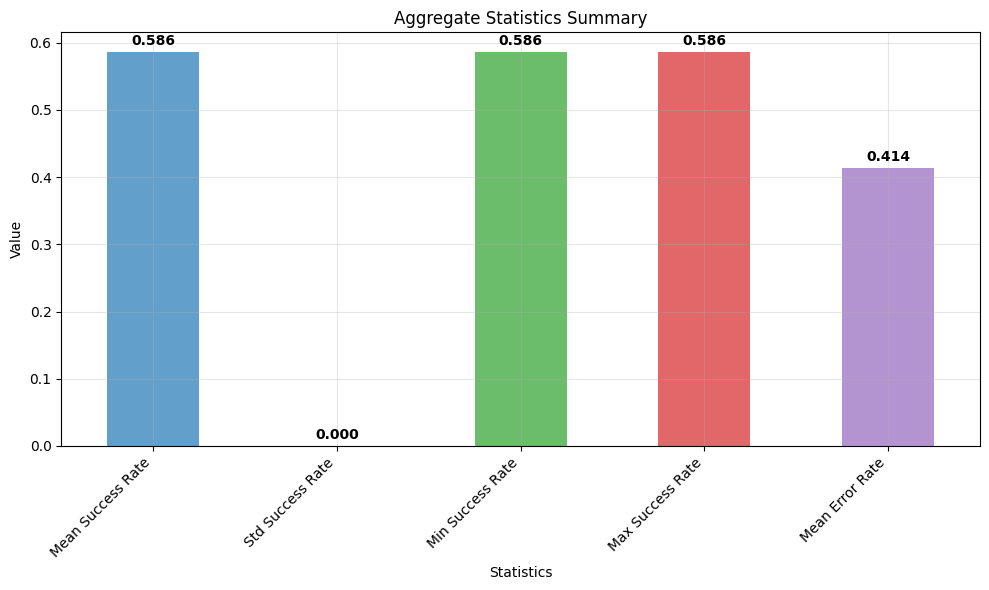

{'CircuitPerformance': {'success_error_comparison': <Figure size 1000x600 with 1 Axes>,
  'shot_distribution': <Figure size 1000x600 with 1 Axes>,
  'aggregate_summary': <Figure size 1000x600 with 1 Axes>}}

In [34]:
rnd_visualizer = Visualizer(metrics_data=rnd_perf_scan.to_dict())
rnd_visualizer.generate_plots(
    selections={Metrics.CIRCUIT_PERFORMANCE: None},
    save=False,
    show=True,
)

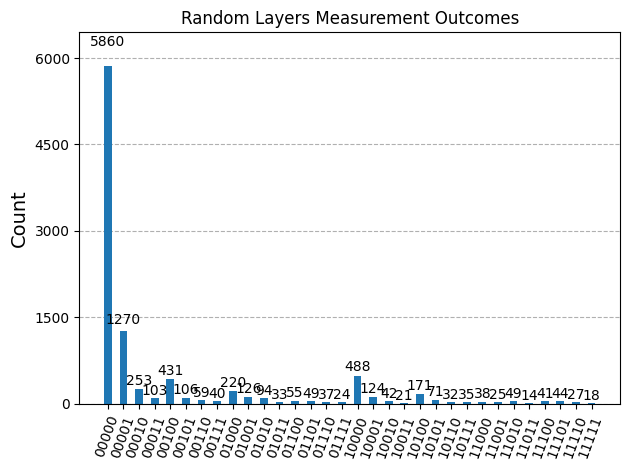

In [35]:
plot_histogram(rnd_noisy_job.result().get_counts(), title="Random Layers Measurement Outcomes")

## Random Layers Benchmark Summary Table

In [36]:
# Full scan: pre-runtime + post-runtime (with DSR)
rnd_full_scan = (
    Scanner(RND)
    .add(
        CircuitPerformanceMetrics,
        job=rnd_noisy_job,
        success_criteria=rnd_success_criteria,
        expected_outcomes=["0" * n],
    )
    .scan(include_all_pre_runtime=True)
)

# Build DataFrame from qward ScanResult
rnd_metrics_df = pd.concat(
    {name: df for name, df in rnd_full_scan.items()},
    axis=1,
)
rnd_metrics_df.columns = [f"{lvl0}.{lvl1}" for lvl0, lvl1 in rnd_metrics_df.columns]

print("=== Random Layers Benchmark: Pre-Runtime + Post-Runtime (DSR) ===")
rnd_metrics_df.T

=== Random Layers Benchmark: Pre-Runtime + Post-Runtime (DSR) ===


,0
CircuitPerformance.individual_jobs.success_metrics.success_rate,0.586
CircuitPerformance.individual_jobs.success_metrics.error_rate,0.414
CircuitPerformance.individual_jobs.success_metrics.total_shots,10000
CircuitPerformance.individual_jobs.success_metrics.successful_shots,5860
CircuitPerformance.individual_jobs.statistical_metrics.entropy,2.552082
CircuitPerformance.individual_jobs.statistical_metrics.uniformity,0.510416
CircuitPerformance.individual_jobs.statistical_metrics.concentration,0.489584
CircuitPerformance.individual_jobs.statistical_metrics.dominant_outcome_probability,0.586
CircuitPerformance.individual_jobs.statistical_metrics.num_unique_outcomes,32
CircuitPerformance.individual_jobs.dsr_metrics.dsr_michelson,0.643759


# Combined Benchmark Comparison

In [37]:
# Use QWARD's actual DSR implementation (histogram-only, no state vectors)
bv_counts = bv_noisy_job.result().get_counts()
qft_counts = qft_noisy_job.result().get_counts()
qpe_counts = qpe_noisy_job.result().get_counts()
rnd_counts = rnd_noisy_job.result().get_counts()

bv_dsr = compute_dsr_michelson(bv_counts, [hidden_string[::-1]])
qft_dsr = compute_dsr_michelson(qft_counts, [hidden_string])
qpe_dsr = compute_dsr_michelson(qpe_counts, [expected])
rnd_dsr = compute_dsr_michelson(rnd_counts, ["0" * n])

# Success rates
bv_success = sum(v for k, v in bv_counts.items() if bv_success_criteria(k)) / sum(bv_counts.values())
qft_success = sum(v for k, v in qft_counts.items() if qft_success_criteria(k)) / sum(qft_counts.values())
qpe_success = sum(v for k, v in qpe_counts.items() if qpe_success_criteria(k)) / sum(qpe_counts.values())
rnd_success = sum(v for k, v in rnd_counts.items() if rnd_success_criteria(k)) / sum(rnd_counts.values())

comparison = pd.DataFrame(
    {
        "Circuit": ["Bernstein-Vazirani", "QFT (roundtrip)", "QPE", "Random Layers"],
        "Success Rate": [bv_success, qft_success, qpe_success, rnd_success],
        "DSR (Michelson)": [bv_dsr, qft_dsr, qpe_dsr, rnd_dsr],
    }
)
comparison = comparison.set_index("Circuit")
print("=== Cross-Circuit Benchmark Comparison (Histogram-Only Metrics) ===")
comparison

=== Cross-Circuit Benchmark Comparison (Histogram-Only Metrics) ===


,Success Rate,DSR (Michelson)
Circuit,,
Bernstein-Vazirani,0.7226,0.675012
QFT (roundtrip),0.6708,0.667412
QPE,0.6800,0.659954
Random Layers,0.5860,0.643759


# Sample Running and experiments

## Qiskit Raw

In [38]:
shot_count = 10000
theta = 0.7
n_samples = [5,10]
hidden_string = "".join(random.choice("01") for _ in range(n))
backend = FakeTorino()  # AerSimulator()#

Hidden string: 01010
Running Bernstein-Vazirani with n=5 qubits...


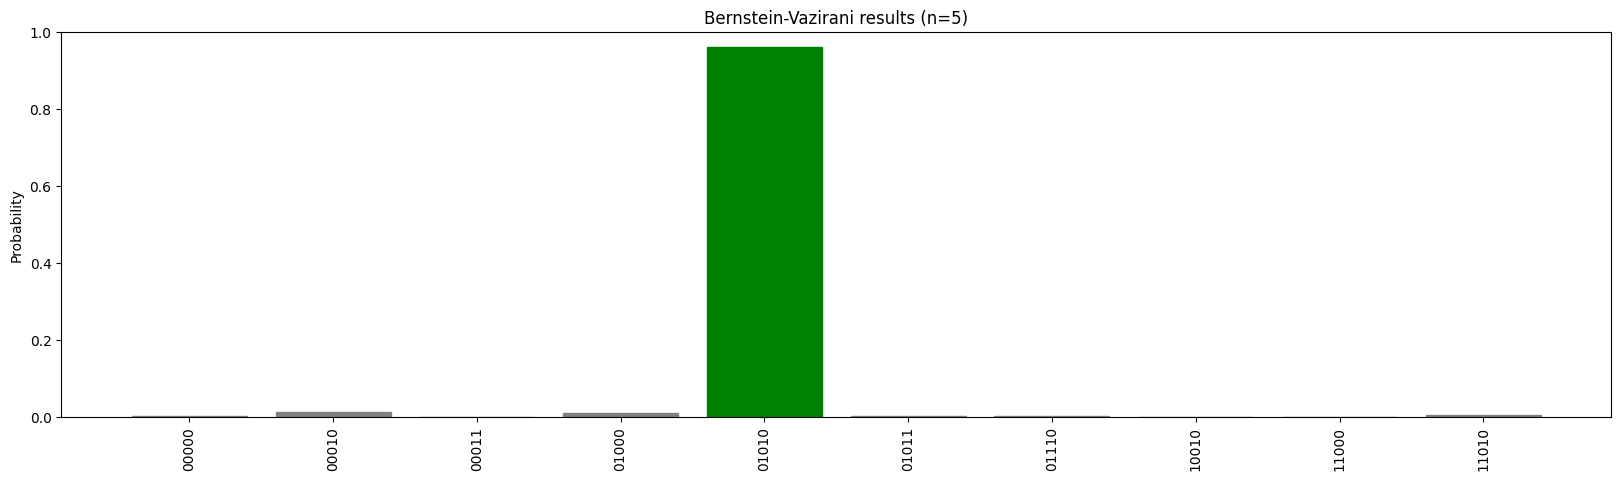

Bernstein-Vazirani Probabilities: {'01010': 0.962, '01000': 0.0108, '00010': 0.0137, '01110': 0.0029, '11010': 0.0057, '10010': 0.0003, '01011': 0.0027, '00000': 0.0017, '11000': 0.0001, '00011': 0.0001}
Success probability: 96.20%
Running QFT (roundtrip) with n=5 qubits...


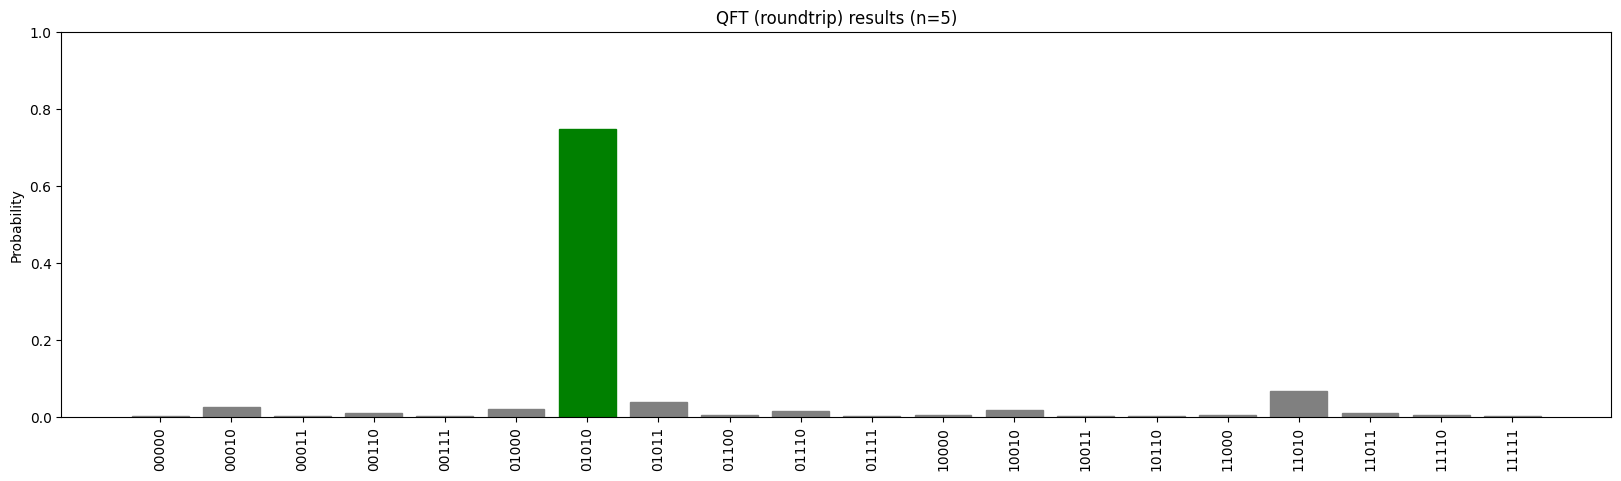

QFT (roundtrip) Probabilities: {'01010': 0.7476, '01001': 0.0011, '01011': 0.0394, '11010': 0.0685, '01110': 0.0155, '11110': 0.0056, '10011': 0.0026, '01000': 0.0216, '00010': 0.026, '11011': 0.0108, '10000': 0.0048, '10110': 0.0029, '01100': 0.0037, '10010': 0.0168, '00011': 0.0032, '11111': 0.0019, '11000': 0.0054, '00110': 0.01, '10111': 0.001, '01111': 0.0023, '11001': 0.0003, '00000': 0.0018, '10101': 0.0003, '11100': 0.0008, '00111': 0.0035, '00100': 0.0009, '01101': 0.0005, '10100': 0.0009, '00101': 0.0001, '10001': 0.0001, '00001': 0.0001}
Success probability: 74.76%
Running QPE with n=5 qubits...


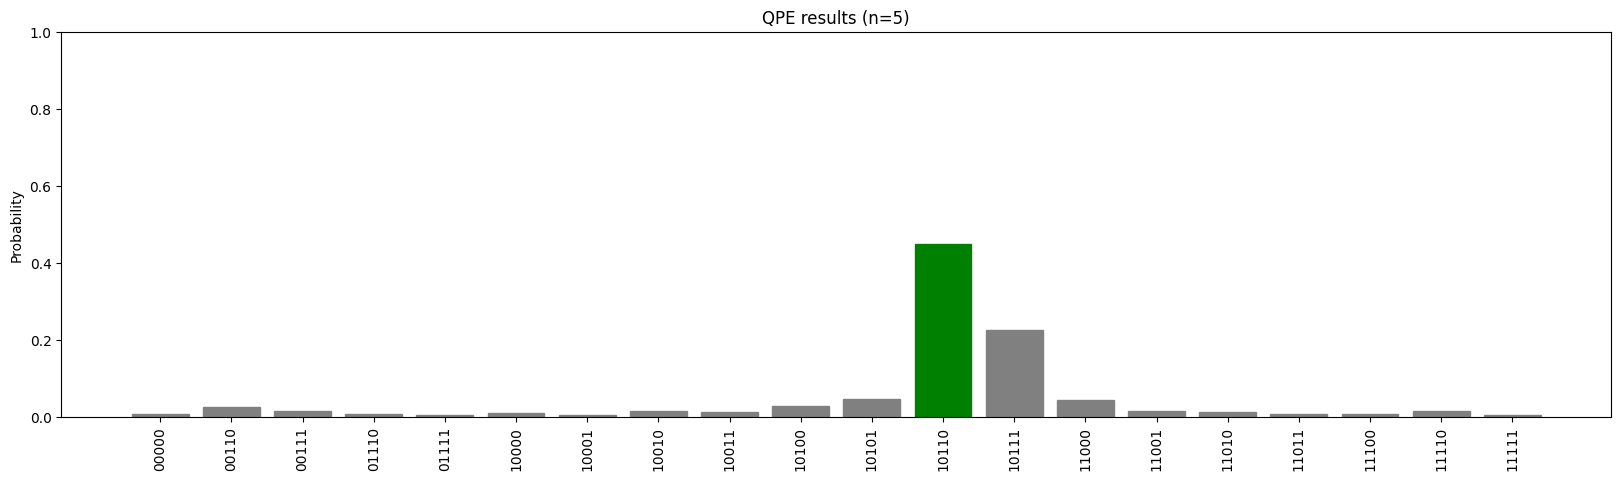

QPE Probabilities: {'10110': 0.4492, '10111': 0.2267, '00100': 0.0039, '10101': 0.0474, '11000': 0.0447, '11011': 0.0076, '01111': 0.0052, '10010': 0.0151, '00111': 0.0158, '11010': 0.0138, '10100': 0.0275, '11100': 0.0066, '01110': 0.007, '01000': 0.0031, '11001': 0.0158, '00110': 0.0263, '01100': 0.0037, '11110': 0.0149, '11101': 0.004, '00000': 0.0071, '10011': 0.0137, '01101': 0.0022, '00101': 0.0043, '01010': 0.0026, '01011': 0.0013, '10000': 0.01, '01001': 0.0024, '00010': 0.0032, '11111': 0.0054, '10001': 0.0053, '00011': 0.0022, '00001': 0.002}
Success probability: 44.92%
Running Random Layers with n=5 qubits...


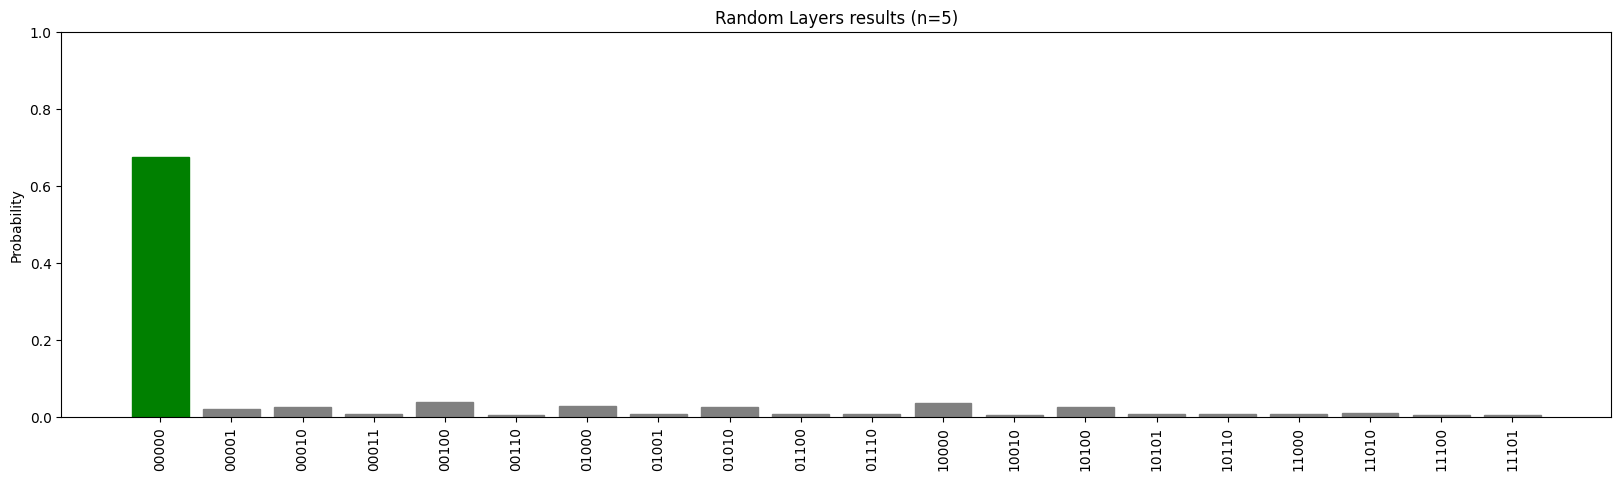

Random Layers Probabilities: {'00000': 0.6746, '10100': 0.0264, '00010': 0.0257, '01000': 0.029, '01001': 0.0075, '00100': 0.0396, '01110': 0.0079, '10010': 0.0061, '10011': 0.0028, '10111': 0.0039, '01101': 0.0038, '11001': 0.0025, '00001': 0.0211, '00110': 0.0058, '10000': 0.0372, '01010': 0.0259, '01100': 0.0081, '11000': 0.0073, '10110': 0.0068, '11010': 0.0101, '11111': 0.0014, '00101': 0.005, '10101': 0.007, '11110': 0.0049, '11101': 0.0059, '01011': 0.0024, '00011': 0.0069, '11100': 0.0064, '11011': 0.0011, '01111': 0.0014, '10001': 0.0033, '00111': 0.0022}
Success probability: 67.46%
Hidden string: 0010010001
Running Bernstein-Vazirani with n=10 qubits...


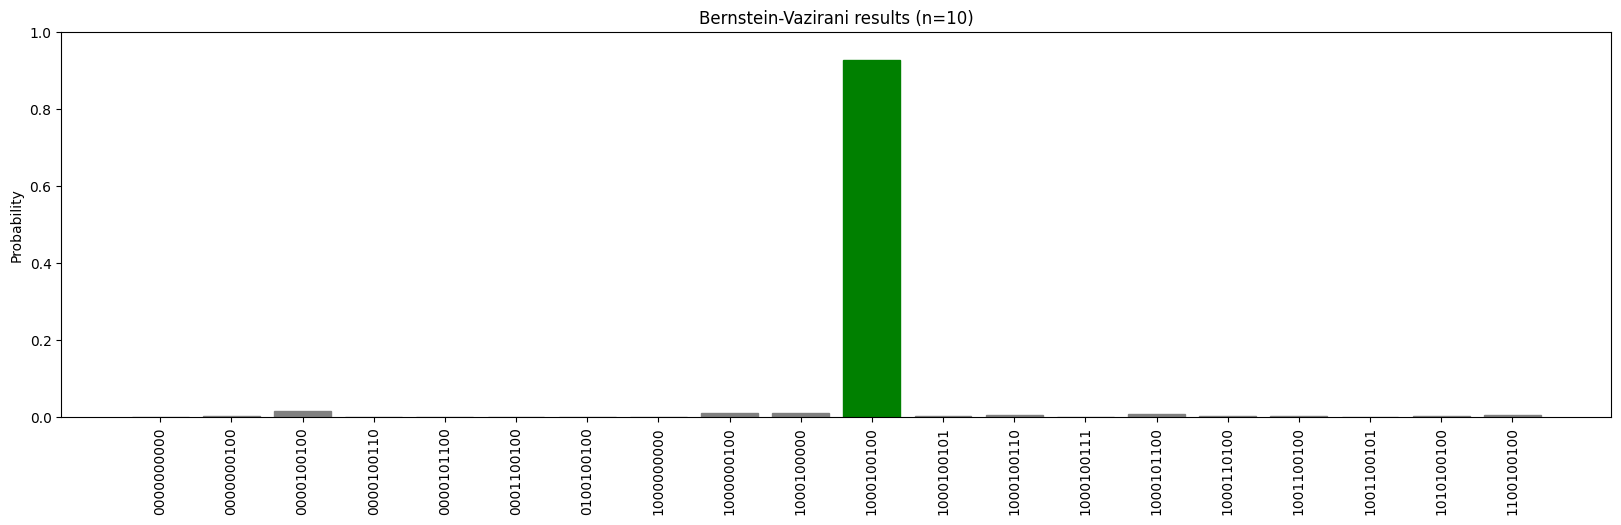

Bernstein-Vazirani Probabilities: {'1000100100': 0.9265, '1000100110': 0.0062, '1100100100': 0.0058, '1000101100': 0.0073, '1000000100': 0.0109, '1000100000': 0.0099, '1010100100': 0.0018, '0000100100': 0.0163, '1000000000': 0.0001, '1000100101': 0.0042, '0000000100': 0.0027, '1001100100': 0.0021, '0000000000': 0.0015, '1000110100': 0.0023, '0100100100': 0.0002, '0000100110': 0.0001, '1000100111': 0.0001, '1000100001': 0.0001, '0001100100': 0.0002, '1100000100': 0.0001, '0010100100': 0.0001, '1000000110': 0.0001, '1000001100': 0.0001, '0000101100': 0.0003, '0000100000': 0.0001, '0000100101': 0.0001, '1000101000': 0.0001, '0100000100': 0.0001, '1001100101': 0.0002, '1010110100': 0.0001, '1000110110': 0.0001, '1000000101': 0.0001, '1100100000': 0.0001}
Success probability: 92.65%
Running QFT (roundtrip) with n=10 qubits...


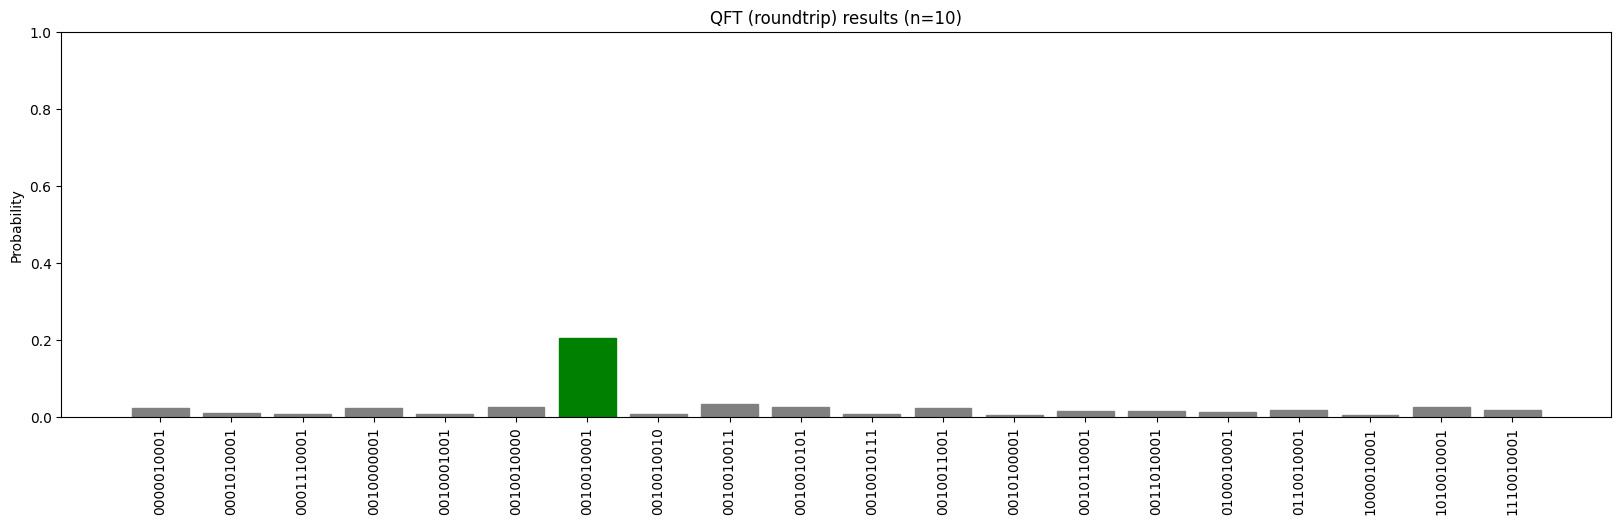

QFT (roundtrip) Probabilities: {'0010010001': 0.2062, '0000110011': 0.0011, '0100001001': 0.0007, '1010011000': 0.0008, '0000000001': 0.0043, '1001010011': 0.0005, '0011010001': 0.0152, '0001010001': 0.0107, '1010110001': 0.0028, '0010001001': 0.0069, '0010110001': 0.0163, '0001110111': 0.0004, '0010010101': 0.0258, '0010000001': 0.025, '0010010000': 0.026, '1000010001': 0.0068, '0100010011': 0.003, '0000010101': 0.0046, '1100010011': 0.0006, '0001111001': 0.0029, '0111010011': 0.0004, '0000010011': 0.0056, '0010011001': 0.0226, '0110010001': 0.0176, '1010010101': 0.0039, '0100011001': 0.0029, '0111111011': 0.0001, '0010110101': 0.0036, '0010001000': 0.0015, '1010010011': 0.0058, '0000010001': 0.0237, '1100000001': 0.0011, '0010010011': 0.0341, '0001011001': 0.003, '0011010000': 0.0035, '1010101001': 0.0006, '0010100001': 0.0065, '0001011011': 0.0005, '0011000001': 0.0045, '1010010100': 0.0005, '0001110001': 0.0084, '1010000111': 0.0003, '1010010001': 0.0267, '1110110001': 0.0047, '001

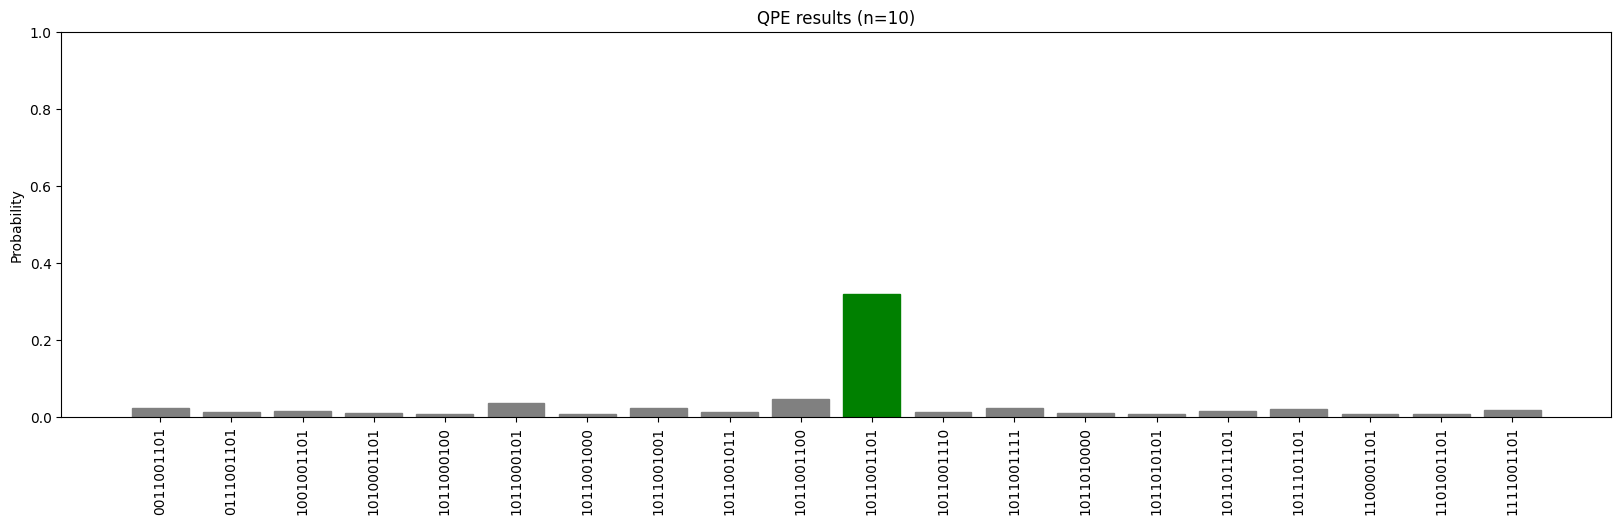

QPE Probabilities: {'1011001101': 0.3201, '0101000111': 0.0001, '0111000101': 0.0025, '1000011101': 0.0008, '1011000100': 0.0068, '1011001001': 0.022, '0011011101': 0.0021, '1011001100': 0.0459, '1011000101': 0.0362, '0000000000': 0.0027, '1100011000': 0.0001, '1010110110': 0.0003, '1100001101': 0.0079, '1011011111': 0.0019, '1010010111': 0.0004, '1011100000': 0.0018, '1100010001': 0.0002, '1011101101': 0.0213, '1000000000': 0.0025, '1001100101': 0.0009, '1110001111': 0.0004, '1010110101': 0.0016, '1011001110': 0.0139, '1011011001': 0.0025, '1111001101': 0.0192, '0010000101': 0.0004, '0110001101': 0.0017, '1110000101': 0.0005, '1011010000': 0.0096, '1111011000': 0.0002, '1011100101': 0.005, '1110101101': 0.0003, '0011000100': 0.0009, '0101111111': 0.0002, '0001000101': 0.0008, '1011010001': 0.0045, '1101001011': 0.0006, '1011011101': 0.0165, '1001101101': 0.0038, '1011010101': 0.0074, '0110101100': 0.0002, '1100001100': 0.0016, '0101001101': 0.0026, '1011000000': 0.0061, '0101011000': 

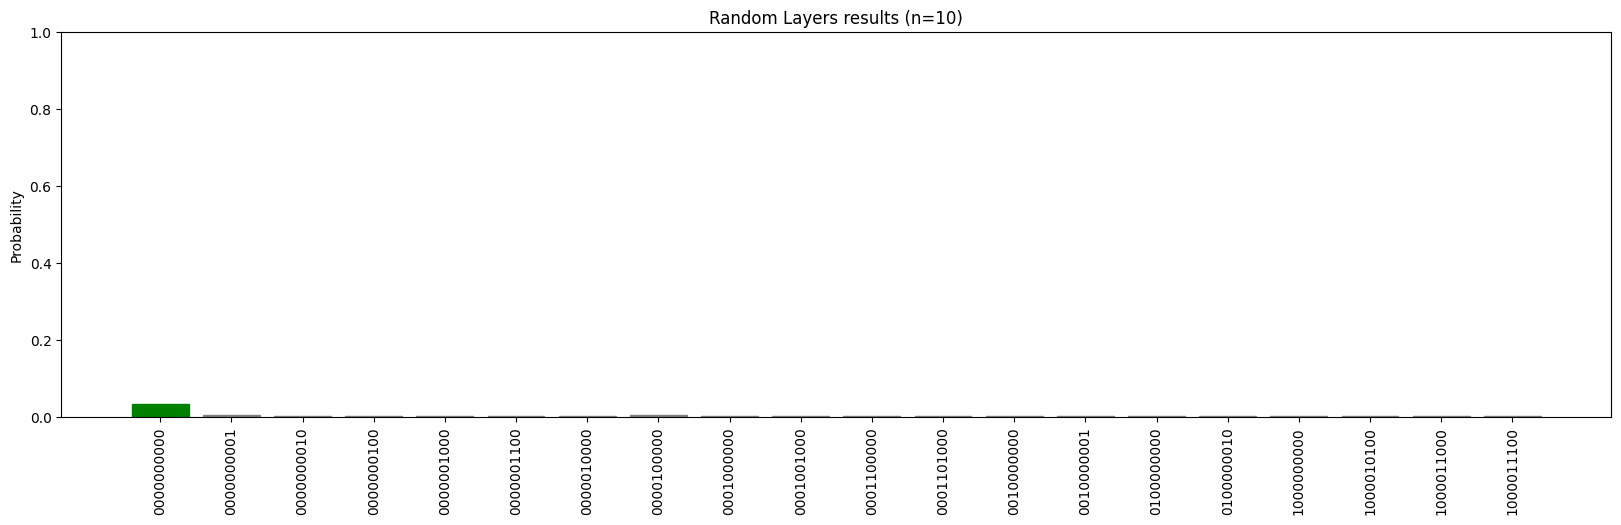

Random Layers Probabilities: {'0000011101': 0.0008, '0010000101': 0.0008, '0001010011': 0.0008, '0011010000': 0.0007, '1011100001': 0.0009, '1001001001': 0.0009, '1101100110': 0.0011, '1011100111': 0.0006, '1100111001': 0.0007, '1001110101': 0.0009, '0001101000': 0.0026, '1100101100': 0.0011, '1110110000': 0.0011, '1110000011': 0.0005, '1011111101': 0.0008, '0000001100': 0.0028, '1011100011': 0.0014, '1001110111': 0.0009, '0100110110': 0.0012, '0111000000': 0.0009, '0110001110': 0.0009, '1000101011': 0.0012, '0001001001': 0.0006, '1110001100': 0.0006, '0001100010': 0.0012, '0100101100': 0.0016, '0100000111': 0.0009, '0100110001': 0.0014, '1011011110': 0.0005, '0000101010': 0.0012, '0100001010': 0.001, '0011100100': 0.001, '1110111000': 0.0004, '0101000010': 0.0011, '1101010010': 0.0009, '0111000111': 0.0014, '1110101110': 0.0007, '1011111001': 0.0007, '0010101001': 0.0007, '0101110111': 0.0012, '1011010110': 0.001, '0100001100': 0.0013, '1011110110': 0.0005, '1100101010': 0.0012, '1000

In [39]:
for n in n_samples:
    hidden_string = "".join(random.choice("01") for _ in range(n))
    m = n
    expected = expected_qpe_bitstring(theta, m)
    print(f"Hidden string: {hidden_string}")
    BV = create_bv_circuit(hidden_string)
    FT = create_FT_circuit(hidden_string)
    QPE = create_QPE_circuit(theta, m)
    RND = create_RND_circuit(n=n, depth=n, seed=42)

    circuits = [BV, FT, QPE, RND]
    circuit_names = ["Bernstein-Vazirani", "QFT (roundtrip)", "QPE", "Random Layers"]

    for circuit, name in zip(circuits, circuit_names):
        print(f"Running {name} with n={n} qubits...")
        isa_qc = pm.run(circuit)
        sampler = Sampler(mode=backend)
        sampler_result = sampler.run([isa_qc], shots=shot_count).result()
        counts = sampler_result[0].data.c.get_counts()
        if name == "Bernstein-Vazirani":
            hidden_bitstring=hidden_string
        elif name == "QFT (roundtrip)":
            hidden_bitstring=hidden_string[::-1]
        elif name == "QPE":
            hidden_bitstring=expected[::-1]
        else:
             hidden_bitstring="0" * n
             
        results = bitstring_count_to_probabilities(
             data=counts, shot_count=shot_count, number_of_counting_qubits=len(hidden_string)
        )     
        Prob = plot_results(
            counts,
            hidden_bitstring=hidden_bitstring,
            title=f"{name} results (n={n})",
            max_columns=20,
        )
        print(f"{name} Probabilities:", Prob)
        if name != "QPE":
            print(f"Success probability: {100 * results.get(hidden_bitstring[::-1], 0):.2f}%")
        else:
            print(f"Success probability: {100 * results.get(expected, 0):.2f}%")   
            
    